- (base) root@esa-adb-gpu:~/Master_Thesis# conda create -n flam_env python=3.10 -y
- conda activate flam_env
- git clone https://github.com/owkin/FLamby.git
- cd FLamby
- make enable=fed_tcga_brca install # This installs FLamby plus only the dependencies for Fed-TCGA-BRCA.

In [ ]:
import sys
print(sys.executable)

In [4]:
import sys
print(sys.executable)
print(sys.path)

/Users/nataliamorenoblasco/anaconda3/envs/flam_env/bin/python
['/Users/nataliamorenoblasco/Desktop/Master_Thesis', '/Users/nataliamorenoblasco/anaconda3/envs/flam_env/lib/python310.zip', '/Users/nataliamorenoblasco/anaconda3/envs/flam_env/lib/python3.10', '/Users/nataliamorenoblasco/anaconda3/envs/flam_env/lib/python3.10/lib-dynload', '', '/Users/nataliamorenoblasco/anaconda3/envs/flam_env/lib/python3.10/site-packages']


In [2]:
import sys
print(sys.executable)

/root/miniconda3/envs/flamby/bin/python


In [1]:
import lifelines
print("Lifelines OK ✅")

Lifelines OK ✅


In [1]:
!which python

/root/miniconda3/envs/flamby/bin/python


# Start here:

In [1]:
from flamby.datasets.fed_tcga_brca import FedTcgaBrca

## 1. Column name extraction:

##### FLamby ready (without col names)

In [6]:
from flamby.datasets.fed_tcga_brca import FedTcgaBrca

# There are 6 centers according to the README
centers = list(range(6))

total_train = 0
total_test = 0
num_features = None

for center in centers:
    # Load train and test sets for each center
    train_ds = FedTcgaBrca(center=center, train=True)
    test_ds = FedTcgaBrca(center=center, train=False)

    total_train += len(train_ds)
    total_test += len(test_ds)

    # Get number of features from one sample
    if num_features is None and len(train_ds) > 0:
        X, y = train_ds[0]
        num_features = X.numel()

print(f"Number of centers: {len(centers)}")
print(f"Train samples total: {total_train}")
print(f"Test samples total: {total_test}")
print(f"Total samples (train + test): {total_train + total_test}")
print(f"Number of features per sample: {num_features}") # without including E and T so in total 41

Number of centers: 6
Train samples total: 866
Test samples total: 222
Total samples (train + test): 1088
Number of features per sample: 39


/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


##### brca.csv (col names)

In [7]:
import pandas as pd
import os
import flamby.datasets.fed_tcga_brca as brca_module

# 1. Automatically locate the CSV inside the FLamby package
base_path = os.path.dirname(brca_module.__file__)
csv_path = os.path.join(base_path, "brca.csv")

print(f"→ Loading: {csv_path}")

# 2. Load the CSV
df_brca = pd.read_csv(csv_path)

# 3. Display shape and column info
n_rows, n_cols = df_brca.shape
print(f"\nNumber of data points (rows): {n_rows}")
print(f"Number of columns (including targets): {n_cols}")

# 4. Inspect first few columns to see feature names
print("\nFirst 10 column names:")
print(df_brca.columns[:10].tolist())

# 5. If the file includes 'event' and 'time' at the end, subtract 2 to get #features
feature_cols = [c for c in df_brca.columns if c not in ["event", "time"]]
print(f"\nNumber of features (excluding 'event' and 'time'): {len(feature_cols)}")


→ Loading: /Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/brca.csv

Number of data points (rows): 1096
Number of columns (including targets): 42

First 10 column names:
['pid', 'age_at_index', 'ethnicity_not hispanic or latino', 'ethnicity_not reported', 'race_asian', 'race_black or african american', 'race_not reported', 'race_white', 'ajcc_pathologic_m_MX', 'ajcc_pathologic_n_N0 (i-)']

Number of features (excluding 'event' and 'time'): 42


In [9]:
import pandas as pd
import os
import flamby.datasets.fed_tcga_brca as brca_module

# 1. Locate brca.csv automatically
base_path = os.path.dirname(brca_module.__file__)
csv_path = os.path.join(base_path, "brca.csv")

# 2. Load the CSV
df_brca = pd.read_csv(csv_path)

# 3. Count missing values per column
nan_counts = df_brca.isna().sum()

# 4. Filter to show only columns that have at least one NaN
nan_columns = nan_counts[nan_counts > 0]

print(f"→ Total rows: {len(df_brca)}")
print(f"→ Columns with missing values: {len(nan_columns)}\n")
print(nan_columns)

# (Optional) summarize total NaNs
print(f"\nTotal missing values in dataset: {df_brca.isna().sum().sum()}")

→ Total rows: 1096
→ Columns with missing values: 0

Series([], dtype: int64)

Total missing values in dataset: 0


##### For FLamby ready use (the one without col names:)
- Number of centers: 6
- Total samples (train + test): 1088
- Number of features per sample: 39 (without E and T, so in total 41)

##### brca.csv --> preprocessed data (includes col names:)
- Number of data points (rows): 1096 --> 8 patients difference
- Number of columns (including targets): 42 (includes PID which is not needed, so ok same number of features in both)


In [14]:
import pandas as pd
import os
import flamby.datasets.fed_tcga_brca as brca_module

# Locate the dataset folder
base_path = os.path.dirname(brca_module.__file__)
split_path = os.path.join(base_path, "dataset_creation_scripts", "train_test_split.csv")

# Load the split file
df_split = pd.read_csv(split_path)

# Count unique pids
n_total_rows = len(df_split)
n_unique_pids = df_split["pid"].nunique()

print(f"Total rows in train_test_split.csv: {n_total_rows}")
print(f"Unique patient IDs (pids): {n_unique_pids}")

# Optional: check for duplicates
duplicates = df_split["pid"].duplicated().sum()
print(f"Duplicate patient IDs: {duplicates}")


Total rows in train_test_split.csv: 1088
Unique patient IDs (pids): 1088
Duplicate patient IDs: 0


The reason why in brca.csv there are 1096 patients and in FedTcgaBrca dataset are 1088 patients is bc the filtering logic in dataset.py. In this script, the class FedTcgaBrca loads all patient records from brca.csv but then restricts them to those whose identifiers (pid) appear in the predefined file train_test_split.csv. This split file lists exactly 1088 unique patients used for the static train/test partitions. Since 8 patient IDs from brca.csv are not included in train_test_split.csv, they are automatically excluded by the line
self.data = df2[df2["pid"].isin(pid_list)]. Thus, the 8-patient difference is not due to missing data or unmapped centers, but simply because those patients were omitted from the official split used to build the FLamby benchmark dataset.

However, the features names are still in the same order and are the same, except that in the FedTcgaBrca the PID col is omitted.

Given this, FedTcgaBrca will be used but with the features names for explainability reasons.

### Meaning of variables:
- age_at_index: The patient's age (in years) on the reference or anchor date used during date obfuscation. (integer or null)
- ethnicity_not hispanic or latino: An individual's self-described social and cultural grouping, specifically whether an individual describes themselves as Hispanic or Latino. The provided values are based on the categories defined by the U.S. Office of Management and Business and used by the U.S. Census Bureau. (binary)
    - ethnicity_not reported: binary
- race_asian: An arbitrary classification of a taxonomic group that is a division of a species. It usually arises as a consequence of geographical isolation within a species and is characterized by shared heredity, physical attributes and behavior, and in the case of humans, by common history, nationality, or geographic distribution. The provided values are based on the categories defined by the U.S. Office of Management and Business and used by the U.S. Census Bureau. (binary)
    - race_black or african american: binary
    - race_not reported: binary
    - race_white: binary
- ajcc_pathologic_m_MX: The codes that represent the stage of cancer based on the nodes present (N stage) according to criteria based on multiple editions of the AJCC's Cancer Staging Manual. (binary)
    - ajcc_pathologic_n_N0 (i-): binary
    - ajcc_pathologic_n_N1: binary
    - ajcc_pathologic_n_N1a: binary
    - ajcc_pathologic_n_N2: binary
    - ajcc_pathologic_n_N2a: binary
- ajcc_pathologic_stage_Stage IA: The extent of a cancer, especially whether the disease has spread from the original site to other parts of the body based on AJCC staging criteria. (binary)
    - ajcc_pathologic_stage_Stage IIA: binary
    - ajcc_pathologic_stage_Stage IIB: binary
    - ajcc_pathologic_stage_Stage IIIA: binary
    - ajcc_pathologic_stage_Stage IIIC: binary
- ajcc_pathologic_t_T1c: Code of pathological T (primary tumor) to define the size or contiguous extension of the primary tumor (T), using staging criteria from the American Joint Committee on Cancer (AJCC).
    - ajcc_pathologic_t_T2:
    - ajcc_pathologic_t_T3:
- ajcc_staging_system_edition_5th: The text term used to describe the version or edition of the American Joint Committee on Cancer Staging Handbooks, a publication by the group formed for the purpose of developing a system of staging for cancer that is acceptable to the American medical profession and is compatible with other accepted classifications.
    - ajcc_staging_system_edition_6th:
    - ajcc_staging_system_edition_7th:
- icd_10_code_C50.9: Alphanumeric value used to describe the disease code from the tenth version of the International Classification of Disease (ICD-10).
    - morphology_8500/3:
    - morphology_8520/3:
- "primary_diagnosis_Infiltrating duct carcinoma, NOS":Text term used to describe the patient's histologic diagnosis, as described by the World Health Organization's (WHO) International Classification of Diseases for Oncology (ICD-O).
    - "primary_diagnosis_Lobular carcinoma, NOS":
- prior_malignancy_yes: The yes/no/unknown indicator used to describe the patient's history of prior cancer diagnosis.
- synchronous_malignancy_Not Reported: A yes/no/unknown indicator used to describe whether the patient had an additional malignant diagnosis at the same time the tumor used for sequencing was diagnosed. If both tumors were sequenced, both tumors would have synchronous malignancies.
- treatment_or_therapy_not reported: A yes/no/unknown/not applicable indicator related to the administration of therapeutic agents received.
    - treatment_or_therapy_yes
- tumor_stage_stage i: The extent of a cancer in the body. Staging is usually based on the size of the tumor, whether lymph nodes contain cancer, and whether the cancer has spread from the original site to other parts of the body. The accepted values for tumor_stage depend on the tumor site, type, and accepted staging system. These items should accompany the tumor_stage value as associated metadata.
    - tumor_stage_stage ia
    - tumor_stage_stage iia
    - tumor_stage_stage iib
    - tumor_stage_stage iiia
    - tumor_stage_stage iiic
- E (event): whether the patient died (1) or was censored (0) 
    - if 0 = the patient was still alive at last follow-up (so their survival time is “censored”).
    - if 1 = event of interest (death) happened.
- T (time): time that has passed until the event  (in days). --> paper: https://arxiv.org/pdf/2006.08997
    - t represents “the time during which we have information about the patient.”
        - If the event happened → it’s the time to event.
        - If not → it’s the time to censoring (end of observation).
    

In [8]:
# Example: load training data for center 0
center0_train = FedTcgaBrca(center=0, train=True, pooled=False)

print("Center 0 - Training samples:", len(center0_train))

# Inspect one sample
X, y = center0_train[0]
print("Features shape:", X.shape)
print("Label:", y)

Center 0 - Training samples: 248
Features shape: torch.Size([39])
Label: tensor([  1., 921.])


/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


### Read data from center 0: with no features

In [ ]:
import pandas as pd
import torch
from flamby.datasets.fed_tcga_brca import FedTcgaBrca

# Load training set for center 0
center0_train = FedTcgaBrca(center=0, train=True) 

"""
train=True → loads the training split of Center 0

train=False → loads the test split of Center 0

pooled=True → ignores centers and merges everything into one pooled dataset (train or test depending on the flag)
"""

# Convert to DataFrame
features_list = []
labels_list = []

for X, y in center0_train:
    features_list.append(X.numpy())
    labels_list.append(y.numpy())

df_features = pd.DataFrame(features_list)
df_labels = pd.DataFrame(labels_list, columns=["event", "time"])

# Combine features + labels
df_center0 = pd.concat([df_features, df_labels], axis=1)

# Show all rows/columns (careful, it may be big)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Rename columns to something clearer
df_center0.columns = [f"feature_{i}" for i in range(39)] + ["event", "time"]
df_center0.head()  # or df_center0 to print everything


/root/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,event,time
0,60.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,921.0
1,43.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1325.0
2,89.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1545.0
3,50.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1142.0
4,63.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2329.0


### Read data from center 0: with features (brom brca.csv)

In [3]:
import pandas as pd
import torch
from flamby.datasets.fed_tcga_brca import FedTcgaBrca
import os

# Load training set for center 0
center0_train = FedTcgaBrca(center=0, train=True)

# --- STEP 1: Get feature names from the original CSV ---
# (You can adapt this path if needed)
csv_path = os.path.join(
    os.path.dirname(__import__('flamby').__file__),
    "datasets/fed_tcga_brca/brca.csv"
)
df_full = pd.read_csv(csv_path)

# The first column is "pid", features are columns 1:40, labels are columns 40:42
feature_names = df_full.columns[1:40].tolist()
label_names = df_full.columns[40:42].tolist()  # ["E", "T"]

# --- STEP 2: Build DataFrame from dataset tensors ---
features_list = []
labels_list = []

for X, y in center0_train:
    features_list.append(X.numpy())
    labels_list.append(y.numpy())

df_features = pd.DataFrame(features_list, columns=feature_names)
df_labels = pd.DataFrame(labels_list, columns=label_names)

# --- STEP 3: Combine features + labels ---
df_center0 = pd.concat([df_features, df_labels], axis=1)

# Optional: view all columns
pd.set_option("display.max_columns", None)

print(df_center0.head())

   age_at_index  ethnicity_not hispanic or latino  ethnicity_not reported  \
0          60.0                               0.0                     1.0   
1          43.0                               1.0                     0.0   
2          89.0                               1.0                     0.0   
3          50.0                               1.0                     0.0   
4          63.0                               0.0                     0.0   

   race_asian  race_black or african american  race_not reported  race_white  \
0         0.0                             0.0                0.0         1.0   
1         0.0                             0.0                0.0         1.0   
2         0.0                             1.0                0.0         0.0   
3         0.0                             0.0                0.0         1.0   
4         0.0                             0.0                0.0         1.0   

   ajcc_pathologic_m_MX  ajcc_pathologic_n_N0 (i-)  ajcc

/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


In [15]:
import pandas as pd
import torch
from flamby.datasets.fed_tcga_brca import FedTcgaBrca

# Load training set for center 0
center1_train = FedTcgaBrca(center=1, train=True) 

# Convert to DataFrame
features_list = []
labels_list = []

for X, y in center1_train:
    features_list.append(X.numpy())
    labels_list.append(y.numpy())

df_features = pd.DataFrame(features_list)
df_labels = pd.DataFrame(labels_list, columns=["event", "time"])

# Combine features + labels
df_center1 = pd.concat([df_features, df_labels], axis=1)

# Show all rows/columns (careful, it may be big)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Rename columns to something clearer
df_center1.columns = [f"feature_{i}" for i in range(39)] + ["event", "time"]
df_center1.head()  # or df_center0 to print everything

/root/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,event,time
0,63.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,343.0
1,41.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1604.0
2,49.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2108.0
3,61.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2097.0
4,68.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3088.0


In [9]:
from flamby.datasets.fed_tcga_brca import TcgaBrcaRaw, FedTcgaBrca

# Raw dataset
mydataset_raw = TcgaBrcaRaw()

# Pooled test dataset
mydataset_pooled = FedTcgaBrca(train=False, pooled=True)

# Center 2 train dataset
mydataset_local2= FedTcgaBrca(center=2, train=True, pooled=False)

# Computing the length of mydataset_local2
N = len(mydataset_local2)

# Accessing individual samples
X, y = mydataset_local2[N // 2]

/root/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


In [10]:
from flamby.datasets.fed_tcga_brca import TcgaBrcaRaw

raw_dataset = TcgaBrcaRaw()
print("Raw samples:", len(raw_dataset))

Raw samples: 1096


In [12]:
import pandas as pd

features_list = []
labels_list = []

for X, y in raw_dataset:
    features_list.append(X.numpy())
    labels_list.append(y.numpy())

df_features = pd.DataFrame(features_list)
df_labels = pd.DataFrame(labels_list, columns=["event", "time"])

df_raw = pd.concat([df_features, df_labels], axis=1)

# Show nicely in Jupyter
df_raw.head()   # or just df_raw


/root/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,event,time
0,90.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,538.0
1,90.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,677.0
2,90.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,174.0
3,55.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2072.0
4,52.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,678.0


## 2. Exploratory Data Analysis (EDA)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from flamby.datasets.fed_tcga_brca import FedTcgaBrca

In [12]:
# Prints info of all centers in train and test (since they are already splited)
all_centers = []

for center in range(6):
    # Load both train and test
    for mode in [True, False]:  # True=train, False=test
        dataset = FedTcgaBrca(center=center, train=mode)
        X_list, y_list = [], []

        for X, y in dataset:
            X_list.append(X.numpy())
            y_list.append(y.numpy())

        df_X = pd.DataFrame(X_list)
        df_y = pd.DataFrame(y_list, columns=["event", "time"])
        df_center = pd.concat([df_X, df_y], axis=1)
        df_center["center"] = center
        df_center["split"] = "train" if mode else "test"  # optional column
        all_centers.append(df_center)

# combine into single dataframe
df_all = pd.concat(all_centers, ignore_index=True)
df_all.columns = [f"feature_{i}" for i in range(df_all.shape[1]-4)] + ["event", "time", "center", "split"]

# Save to CSV
csv_path = "combined_dataset.csv"
df_all.to_csv(csv_path, index=False)

# Print all column names
print("Column names:", df_all.columns.tolist())
print("Combined dataset shape:", df_all.shape)
print("Dataset saved to:", csv_path)
print(df_all.head())

/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))
/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))
/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is d

Column names: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'event', 'time', 'center', 'split']
Combined dataset shape: (1088, 43)
Dataset saved to: combined_dataset.csv
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0       60.0        0.0        1.0        0.0        0.0        0.0   
1       43.0        1.0        0.0        0.0        0.0        0.0   
2       89.0        1.0        0.0        0.0        1.0        0.0   
3       50.0        1.0        0.0        0.0        0.

In [ ]:
# Prints info of all centers in train and test (since they are already splited)
all_centers = []

for center in range(6):
    # Load both train and test
    for mode in [True, False]:  # True=train, False=test
        dataset = FedTcgaBrca(center=center, train=mode)
        X_list, y_list = [], []

        for X, y in dataset:
            X_list.append(X.numpy())
            y_list.append(y.numpy())

        df_X = pd.DataFrame(X_list)
        df_y = pd.DataFrame(y_list, columns=["event", "time"])
        df_center = pd.concat([df_X, df_y], axis=1)
        df_center["center"] = center
        df_center["split"] = "train" if mode else "test"  # optional column
        all_centers.append(df_center)

# combine into single dataframe
df_all = pd.concat(all_centers, ignore_index=True)
df_all.columns = [f"feature_{i}" for i in range(df_all.shape[1]-4)] + ["event", "time", "center", "split"]

print("Combined dataset shape:", df_all.shape)
print(df_all.head())


### Distribution of time feature

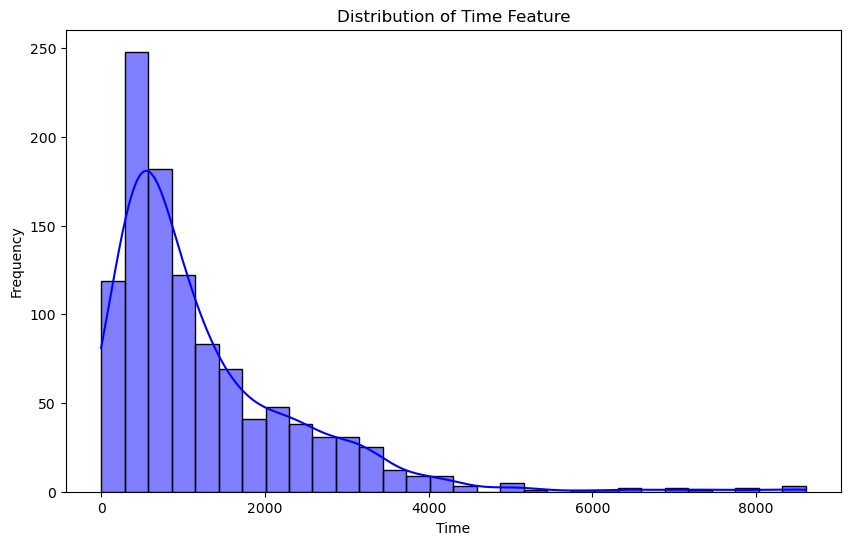

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of the 'time' feature
plt.figure(figsize=(10, 6))
sns.histplot(df_all['time'], kde=True, bins=30, color='blue')
plt.title('Distribution of Time Feature')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

### Distribution of age

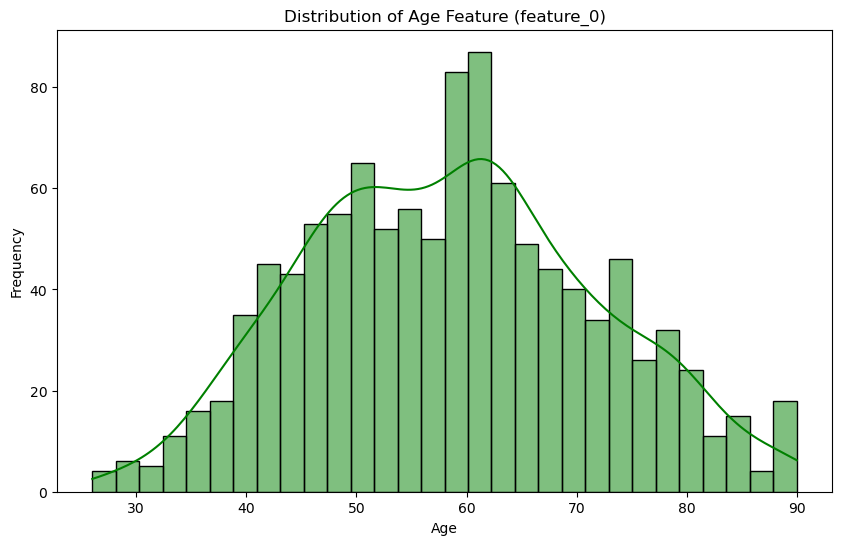

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of the 'age' feature (feature_0)
plt.figure(figsize=(10, 6))
sns.histplot(df_all['feature_0'], kde=True, bins=30, color='green')
plt.title('Distribution of Age Feature (feature_0)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))
/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


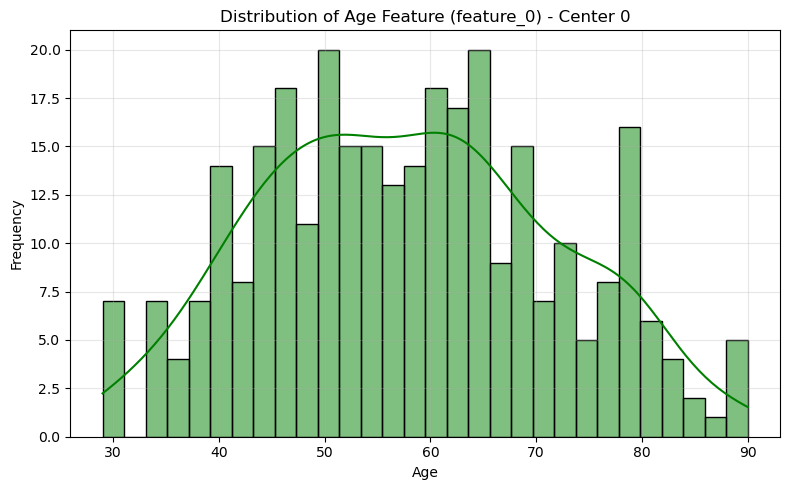

/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))
/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


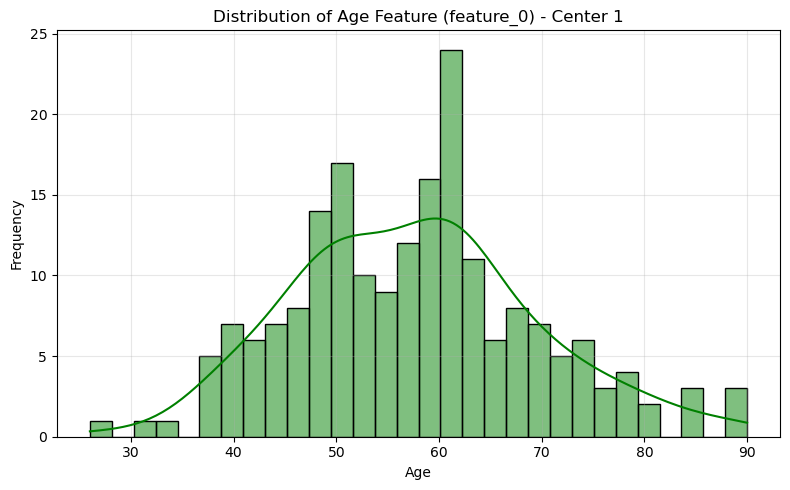

/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))
/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


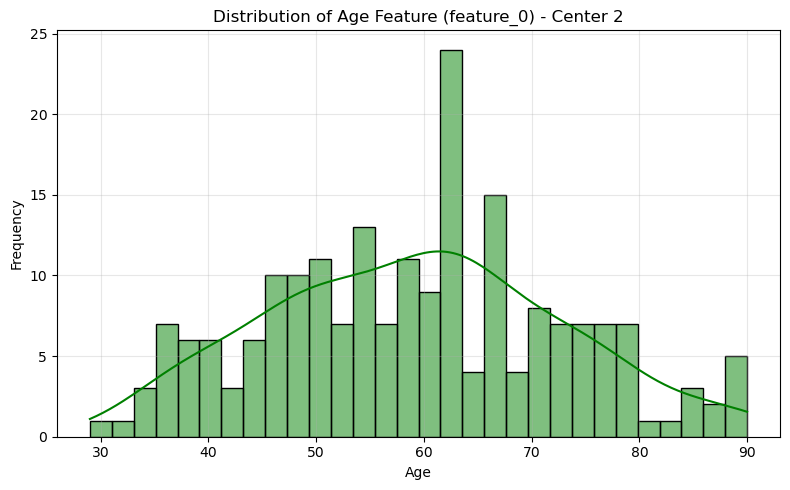

/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))
/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


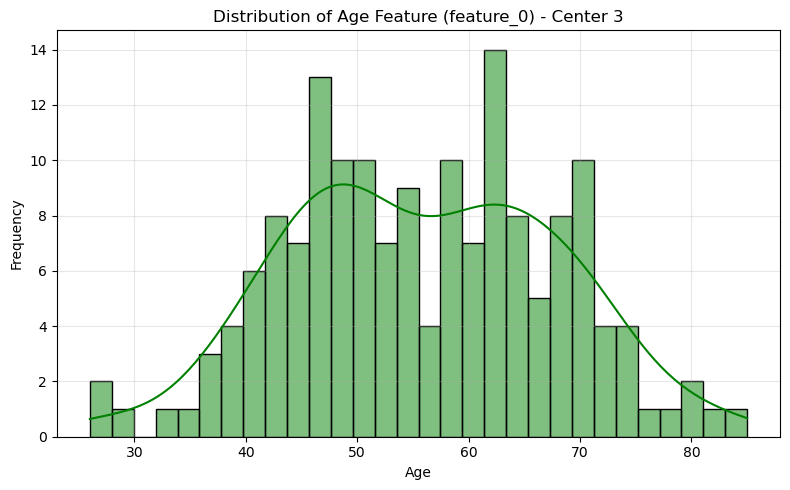

/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))
/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


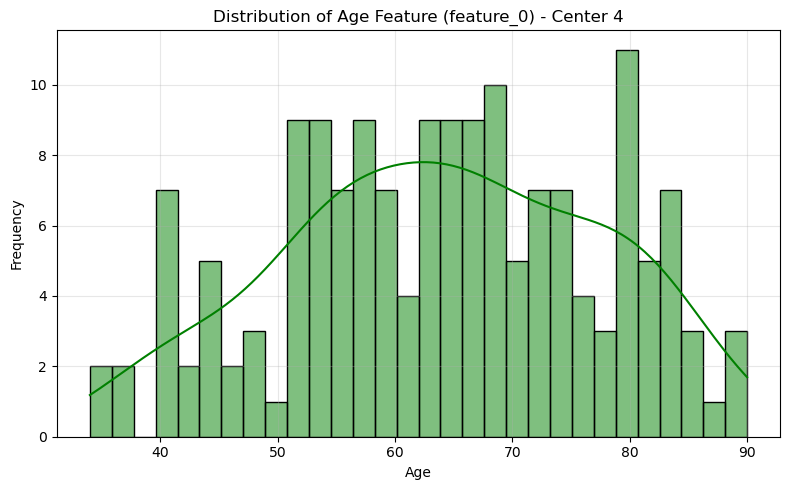

/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))
/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


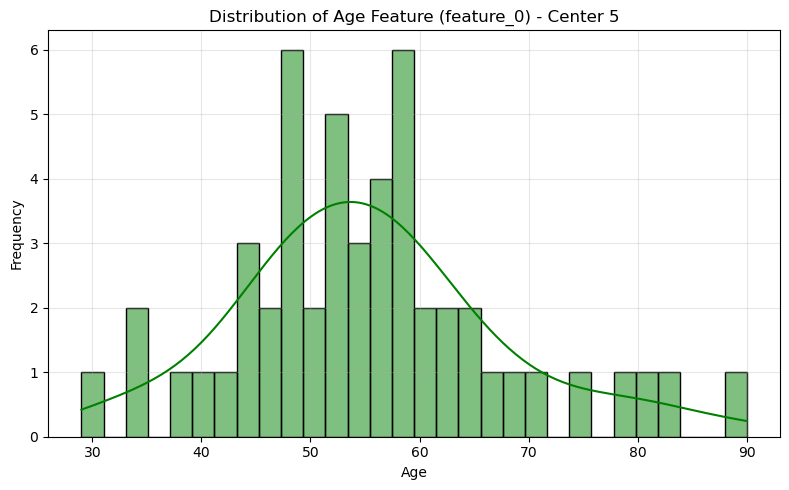

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through centers
for center in range(6):
    # Load both train and test sets for that center
    dfs = []
    for mode in [True, False]:  # True=train, False=test
        dataset = FedTcgaBrca(center=center, train=mode)
        X_list, y_list = [], []

        for X, y in dataset:
            X_list.append(X.numpy())
            y_list.append(y.numpy())

        df_X = pd.DataFrame(X_list)
        df_y = pd.DataFrame(y_list, columns=["event", "time"])
        df_center = pd.concat([df_X, df_y], axis=1)
        df_center["split"] = "train" if mode else "test"
        dfs.append(df_center)

    # Combine train and test for the current center
    df_center_all = pd.concat(dfs, ignore_index=True)
    df_center_all.columns = [
        f"feature_{i}" for i in range(df_center_all.shape[1]-3)
    ] + ["event", "time", "split"]

    # Plot the distribution of the 'age' feature (feature_0)
    plt.figure(figsize=(8, 5))
    sns.histplot(df_center_all["feature_0"], kde=True, bins=30, color="green")
    plt.title(f"Distribution of Age Feature (feature_0) - Center {center}")
    plt.xlabel("Age")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### Check: age-hazard assumption --> Scaled Schoenfeld Residuals
First of all, let’s check the proportional hazard assumptions for our covariates. It is done by a fitted default CoxPH model.

In [2]:
valid_centers = []
for center in getattr(FedTcgaBrca, "all_centers", list(range(6))):
    try:
        _ = FedTcgaBrca(center=center, train=True)
        valid_centers.append(center)
    except Exception as e:
        print(f"Center {center} failed: {e}")
print("Centers successfully loaded:", valid_centers)


Centers successfully loaded: [0, 1, 2, 3, 4, 5]


Processing center 0
Center 0 has 311 samples (train + test).


/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


Detected age column: 0

   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 311 total observations, 252 right-censored observations>
         test_name = proportional_hazard_test

---
        test_statistic    p  -log2(p)
0 km              2.15 0.14      2.81
  rank            4.82 0.03      5.15



1. Variable '0' failed the non-proportional test: p-value is 0.0281.

   Advice 1: the functional form of the variable '0' might be incorrect. That is, there may be non-
linear terms missing. The proportional hazard test used is very sensitive to incorrect functional
forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable '0' using pd.cut, and then specify it in `strata=['0', ...]`
in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-cova

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

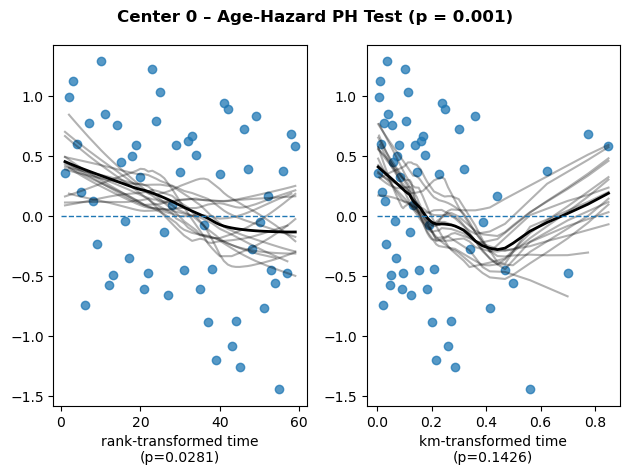

Processing center 1
Center 1 has 196 samples (train + test).
Detected age column: 0

   Bootstrapping lowess lines. May take a moment...



/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


Proportional hazard assumption looks okay.


<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

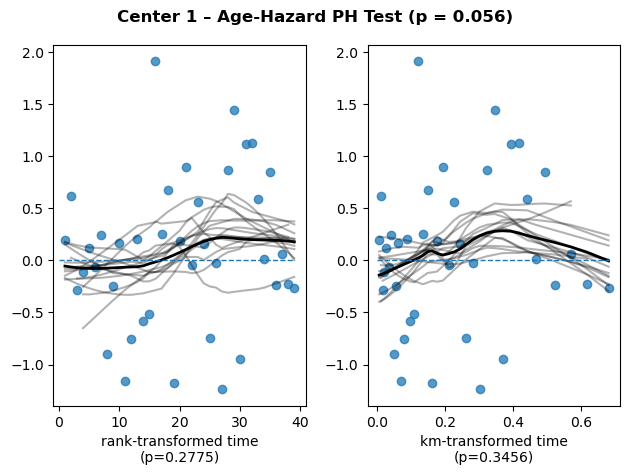

Processing center 2
Center 2 has 206 samples (train + test).
Detected age column: 0

   Bootstrapping lowess lines. May take a moment...



/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


Proportional hazard assumption looks okay.


<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

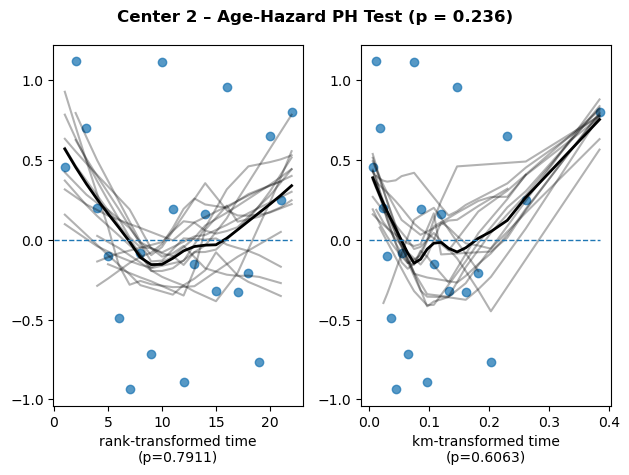

Processing center 3
Center 3 has 162 samples (train + test).


/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


Detected age column: 0

   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

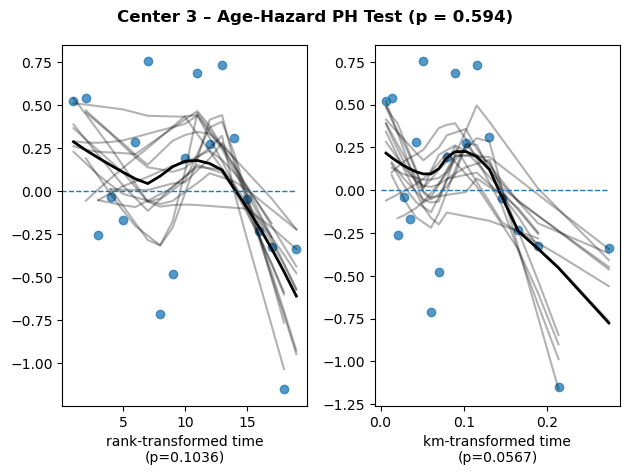

Processing center 4
Center 4 has 162 samples (train + test).
Detected age column: 0

   Bootstrapping lowess lines. May take a moment...



/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))


Proportional hazard assumption looks okay.


<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

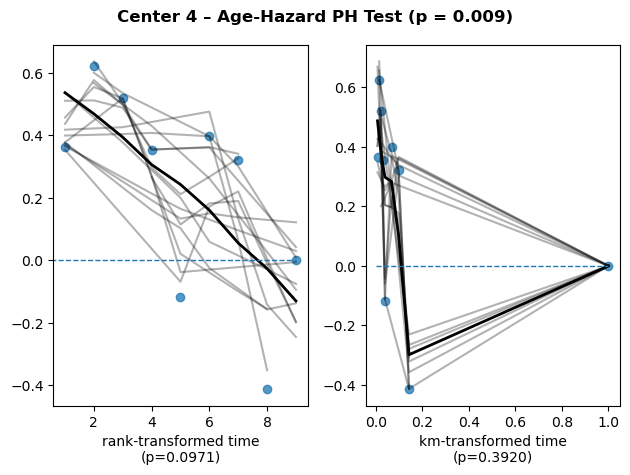

Processing center 5
Center 5 has 51 samples (train + test).
Detected age column: 0

   Bootstrapping lowess lines. May take a moment...



/Users/nataliamorenoblasco/Desktop/Master_Thesis/FLamby/flamby/datasets/fed_tcga_brca/dataset.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (torch.tensor(x, dtype=self.X_dtype), torch.tensor(y, dtype=self.y_dtype))
/Users/nataliamorenoblasco/anaconda3/envs/flam_env/lib/python3.10/site-packages/lifelines/utils/lowess.py:54: LinAlgWarning: Ill-conditioned matrix (rcond=5.55112e-17): result may not be accurate.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)
/Users/nataliamorenoblasco/anaconda3/envs/flam_env/lib/python3.10/site-packages/lifelines/utils/lowess.py:54: LinAlgWarning: Ill-conditioned matrix (rcond=1.23358e-17): result may not be accurate.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)
/Users/nataliamorenoblasco/anaconda3/envs/flam_env/lib/python

Proportional hazard assumption looks okay.


<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

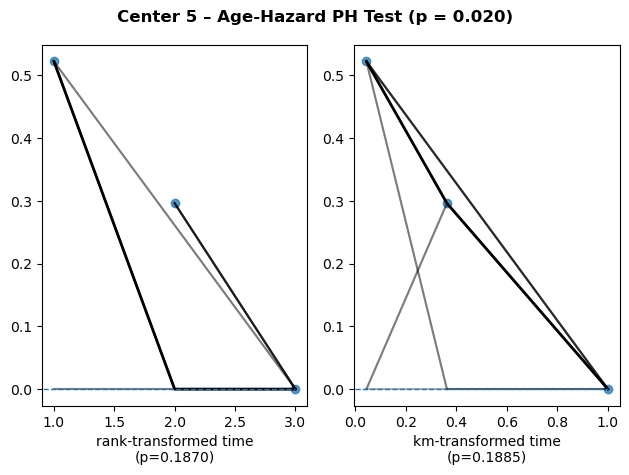


=== Summary of PH test for age ===
   center   p_value
0       0  0.000921
1       1  0.055821
2       2  0.236392
3       3  0.593755
4       4  0.008748
5       5  0.019821


In [5]:
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from itertools import chain
from flamby.datasets.fed_tcga_brca import FedTcgaBrca

results = []

# get centers list from the class if available
centers = getattr(FedTcgaBrca, "all_centers", list(range(6)))

for center in centers:
    print(f"Processing center {center}")
    try:
        train_ds = FedTcgaBrca(center=center, train=True)
        test_ds = FedTcgaBrca(center=center, train=False)
        try:
            total_samples = len(train_ds) + len(test_ds)
        except Exception:
            total_samples = sum(1 for _ in chain(train_ds, test_ds))
        print(f"Center {center} has {total_samples} samples (train + test).")
    except Exception as e:
        print(f"Error loading data for center {center}: {e}")
        results.append({"center": center, "p_value": np.nan})
        continue

    # Combine train and test by iterating both datasets
    X_list, y_list = [], []
    for X, y in chain(train_ds, test_ds):
        X_list.append(X.numpy())
        y_list.append(y.numpy())

    df_X = pd.DataFrame(X_list)
    df_y = pd.DataFrame(y_list, columns=["event", "time"])
    df = pd.concat([df_X, df_y], axis=1)

    # Prefer explicit feature_0 if present, else fallback to first continuous column
    if "feature_0" in df.columns:
        age_col = "feature_0"
    else:
        cont_cols = [c for c in df.columns if df[c].nunique() > 2]
        age_col = cont_cols[0] if cont_cols else None

    if age_col is None:
        print("No continuous 'age' column found — skipping center.")
        results.append({"center": center, "p_value": np.nan})
        continue

    print(f"Detected age column: {age_col}")

    # Standardize age (using combined train+test here)
    df[age_col] = (df[age_col] - df[age_col].mean()) / df[age_col].std(ddof=0)

    # Skip if too few events, but still record a result
    if df["event"].sum() < 3:
        print("⚠️ Skipping: not enough events")
        results.append({"center": center, "p_value": np.nan})
        continue

    # Fit univariate Cox model
    cph = CoxPHFitter(penalizer=0.1)
    try:
        cph.fit(df[[age_col, "time", "event"]],
                duration_col="time", event_col="event", robust=True)
    except Exception as e:
        print(f"Fit error for center {center}: {e}")
        results.append({"center": center, "p_value": np.nan})
        continue

    # Extract p-value from the fitted model summary
    try:
        p_val = float(cph.summary.loc[age_col, "p"])
    except Exception:
        p_val = np.nan

    # Plot PH check (use a fresh figure per center)
    try:
        plt.figure(figsize=(8, 4))
        cph.check_assumptions(df[[age_col, "time", "event"]],
                              p_value_threshold=0.05,
                              show_plots=True,
                              raise_on_violation=False)
        plt.suptitle(f"Center {center} – Age-Hazard PH Test (p = {p_val:.3f})",
                     fontsize=12, weight="bold")
        plt.tight_layout()
        plt.show()
        plt.close()
    except TypeError:
        # older lifelines versions may not accept raise_on_violation
        try:
            plt.figure(figsize=(8, 4))
            cph.check_assumptions(df[[age_col, "time", "event"]],
                                  p_value_threshold=0.05,
                                  show_plots=True)
            plt.suptitle(f"Center {center} – Age-Hazard PH Test (p = {p_val:.3f})",
                         fontsize=12, weight="bold")
            plt.tight_layout()
            plt.show()
            plt.close()
        except Exception as e:
            print(f"Plotting/check_assumptions error for center {center}: {e}")

    results.append({"center": center, "p_value": p_val})

# Print summary of p-values
df_results = pd.DataFrame(results)
print("\n=== Summary of PH test for age ===")
print(df_results)


## INTERPRETATION SCHOENFELD RESIDUAL PLOTS
- In Center 0 (311 patients, 59 events), the Schoenfeld residual test for age gave an overall p = 0.001, indicating a significant violation of the proportional-hazards assumption.
The rank-transformed plot shows a mild downward trend (p = 0.028), while the KM-transformed version is less significant (p = 0.14) but shows some curvature.
Given the high censoring and consistent direction of both curves, the effect of age likely changes slightly over time — age has a stronger impact earlier and weakens later.

- In Center 1 (196 patients, 39 events), the proportional-hazards test for age yielded p = 0.056 (rank p = 0.28, KM p = 0.35).
The Schoenfeld residual plots show only a mild, nonsystematic curvature near mid-time, with the smoothed trend staying close to zero.
Therefore, there’s no strong evidence of a violation of the proportional-hazards assumption for age in this center — the effect of age appears roughly constant over time.

- In Center 2 (206 patients, 22 events), the overall proportional-hazards test for age was not significant (p = 0.236; rank p = 0.79, KM p = 0.61).
Although the Schoenfeld residual plots show a U-shaped smoothing curve, the small number of events likely causes this apparent curvature.
Therefore, there is no meaningful evidence of a violation of the proportional-hazards assumption for age in this center.

- In Center 3 (162 patients, 19 events), the proportional-hazards test for age gave p = 0.59 (rank p = 0.10, KM p = 0.06).
Both residual plots show a mostly flat trend around 0 with minor fluctuations at later times, consistent with random variation due to few late-time events.
Therefore, there is no evidence that the effect of age changes over time in this center.

- In Center 4 (162 patients, 9 events), the global Schoenfeld residual test for age (p = 0.009) suggests a possible violation of the proportional-hazards assumption.
However, both rank- and KM-transformed tests are non-significant, and the residual plots are based on very few events.
The apparent downward trend may reflect random variation rather than a true time-varying effect.
Given the low event count, this result should be interpreted with caution, and the PH assumption is likely approximately valid in practical terms.

- In Center 5 (51 patients, 3 events), the overall Schoenfeld residual test for age yielded p = 0.02, but this is based on only three events.
The residual plots consist of just three points and cannot reveal any meaningful time-dependent pattern.
Therefore, the apparent significance is likely an artifact of extremely low event count, not a genuine violation of the proportional-hazards assumption.



- Given all this:

    - I’ve checked the proportional-hazards (PH) and linearity assumptions for the age variable across all centers using the Schoenfeld residual tests and plots.
            - Center 1 – 311 samples → non-linear age–hazard
            - Center 2 – 196 samples → linear
            - Center 3 – 206 samples → linear
            - Center 4 – 162 samples → linear
            - Center 5 – 162 samples → non-linear
            - Center 6 – 51 samples → non-linear

    - In summary, only Center 0 shows a clear and consistent violation of the proportional-hazards assumption for age. Centers 1–3 behave as expected, while Centers 4–5 are too small to have reliable conclusions.

    - Since I plotted the Schoenfeld residuals for each center, I could see that for some centers the plots did not correspond with the p values, since the nonlinearity in Centers 4 and 5 appears to be due to the fact of having very few events rather than a true time-varying effect. My plan is therefore to try both approaches separately (I don't think they can be combined):
        1. Allow each center to have its own age effect.
        2. Also explore a mixed-effects Cox model.

In [9]:
# Count the number of people for each age
age_counts = df_all['feature_0'].value_counts().sort_index()

# Display the counts
print("\n--- Number of People by Age ---")
print(age_counts)

# Optionally, save the counts to a CSV file
age_counts.to_csv("age_counts.csv", header=['count'], index_label='age')


--- Number of People by Age ---
feature_0
26.0    2
27.0    1
28.0    1
29.0    5
30.0    1
       ..
86.0    1
87.0    3
88.0    6
89.0    3
90.0    9
Name: count, Length: 65, dtype: int64


In [5]:
# Summary by center and split (train/test)
summary = (
    df_all.groupby(["center", "split"])
    .agg(
        n_patients=("event", "count"),
        n_events=("event", "sum"),                      # event = 1
        n_censored=("event", lambda x: (x == 0).sum()), # event = 0
        event_rate=("event", "mean"),
        min_time=("time", "min"),
        max_time=("time", "max"),
        min_age=("feature_0", "min"),              # Minimum age
        max_age=("feature_0", "max"),              # Maximum age
        avg_age=("feature_0", "mean")              # Average age
    )
    .reset_index()
)

# Add percentage version of event rate
summary["event_rate_%"] = (summary["event_rate"] * 100).round(1)
summary["avg_age"] = summary["avg_age"].round(2)  # Round average age for readability

# Totals per center (train + test combined)
summary_center = (
    df_all.groupby("center")
    .agg(
        n_patients=("event", "count"),
        n_events=("event", "sum"),
        n_censored=("event", lambda x: (x == 0).sum()),
        event_rate=("event", "mean"),
        min_time=("time", "min"),
        max_time=("time", "max"),
        min_age=("feature_0", "min"),              # Minimum age
        max_age=("feature_0", "max"),              # Maximum age
        avg_age=("feature_0", "mean")              # Average age
    )
    .reset_index()
)
summary_center["split"] = "all"
summary_center["event_rate_%"] = (summary_center["event_rate"] * 100).round(1)
summary_center["avg_age"] = summary_center["avg_age"].round(2)  # Round average age for readability

# Combine (train/test/all) summaries
summary_full = pd.concat([summary, summary_center], ignore_index=True)

# Totals across all centers and splits:
total_patients = len(df_all)
total_events = (df_all["event"] == 1).sum()
total_censored = (df_all["event"] == 0).sum()
overall_event_rate = total_events / total_patients

summary_total = pd.DataFrame({
    "center": ["Total"],
    "split": ["all"],
    "n_patients": [total_patients],
    "n_events": [total_events],
    "n_censored": [total_censored],
    "event_rate": [overall_event_rate],
    "event_rate_%": [round(overall_event_rate * 100, 1)],
    "min_time": [df_all["time"].min()],
    "max_time": [df_all["time"].max()],
    "min_age": [df_all["feature_0"].min()],
    "max_age": [df_all["feature_0"].max()],
    "avg_age": [round(df_all["feature_0"].mean(), 2)]
})

summary_full = pd.concat([summary_full, summary_total], ignore_index=True)

print("\n--- Totals Across All Centers ---")
print(f"Total patients: {total_patients}")
print(f"Total events (event=1): {total_events}")
print(f"Total censored (event=0): {total_censored}")
print(f"Overall event rate: {overall_event_rate:.2%}")

print("\n--- Summary by Center, Split, and Totals ---")
print(summary_full)

output_path = "summary_by_center_split.csv"
summary_full.to_csv(output_path, index=False)


--- Totals Across All Centers ---
Total patients: 1088
Total events (event=1): 151
Total censored (event=0): 937
Overall event rate: 13.88%

--- Summary by Center, Split, and Totals ---
   center  split  n_patients  n_events  n_censored  event_rate  min_time  \
0       0   test          63      14.0          49    0.222222      76.0   
1       0  train         248      45.0         203    0.181452      64.0   
2       1   test          40       4.0          36    0.100000     187.0   
3       1  train         156      35.0         121    0.224359      78.0   
4       2   test          42       8.0          34    0.190476      10.0   
5       2  train         164      14.0         150    0.085366       1.0   
6       3   test          33       3.0          30    0.090909      24.0   
7       3  train         129      16.0         113    0.124031      21.0   
8       4   test          33       2.0          31    0.060606       0.0   
9       4  train         129       7.0         122   

#### Check rows where min time is <=0:
- There are 14 rows with event 0 where time is 0 or 1 day.
- All patients with survival times ≤ 1 were censored (event = 0), indicating that no events occurred at such early times. These observations likely correspond to cases where follow-up ended before one time unit had elapsed, consistent with the time quantization (Q = 1) described in the dataset’s preprocessing.

In [ ]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# Filter rows where survival time is 1 or less
weird_times = df_all[df_all["time"] <= 1].sort_values(by=["center", "time"]).reset_index(drop=True)

print("\n--- Patients with suspiciously small 'time' values (<= 1) ---")
print(weird_times)


print("\n--- Count of small-time entries by center ---")
print(weird_times["center"].value_counts())


weird_times.to_csv("suspicious_time_entries.csv", index=False)



--- Patients with suspiciously small 'time' values (<= 1) ---
    feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0        56.0        1.0        0.0        0.0        0.0        0.0   
1        80.0        0.0        1.0        0.0        0.0        1.0   
2        79.0        0.0        1.0        0.0        0.0        1.0   
3        74.0        0.0        1.0        0.0        0.0        1.0   
4        66.0        0.0        1.0        0.0        0.0        1.0   
5        83.0        0.0        1.0        0.0        0.0        1.0   
6        67.0        0.0        1.0        0.0        0.0        1.0   
7        75.0        0.0        1.0        0.0        0.0        1.0   
8        73.0        0.0        1.0        0.0        0.0        1.0   
9        66.0        0.0        1.0        0.0        0.0        1.0   
10       43.0        1.0        0.0        1.0        0.0        0.0   
11       65.0        1.0        0.0        0.0        0.0        0.0   
1


Centers available for plotting: ['0' '1' '2' '3' '4' '5' 'Total']


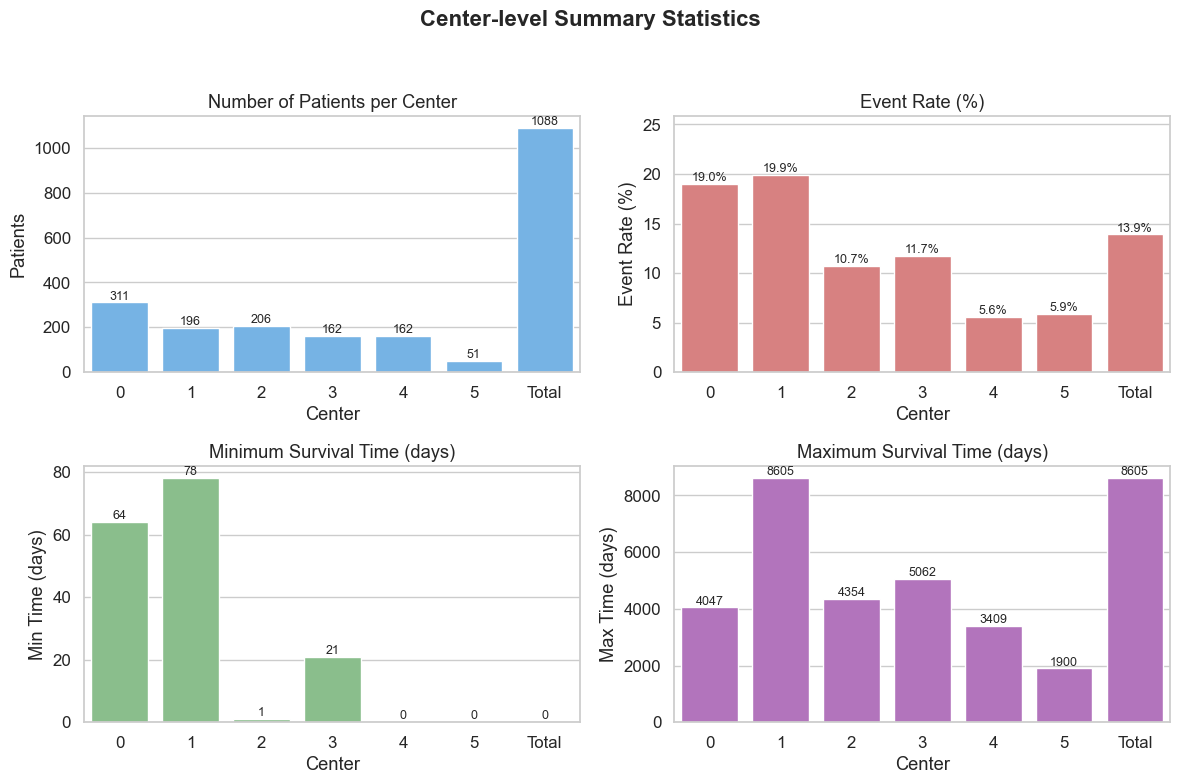

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Preparation of Data:
# Use only the combined ("all") split to get center-level summaries
summary_plot = summary_full[summary_full["split"] == "all"].copy()
summary_plot["center"] = summary_plot["center"].astype(str)

print("\nCenters available for plotting:", summary_plot["center"].unique())

# Creation of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Center-level Summary Statistics", fontsize=16, weight="bold")

# Plot 1: Number of patients per center
sns.barplot(data=summary_plot, x="center", y="n_patients", ax=axes[0, 0], color="#64B5F6")
axes[0, 0].set_title("Number of Patients per Center")
axes[0, 0].set_xlabel("Center")
axes[0, 0].set_ylabel("Patients")
axes[0, 0].bar_label(axes[0, 0].containers[0], fmt="%.0f", fontsize=9, label_type="edge")

# Plot 2: Event rate (percentage) per center 
sns.barplot(data=summary_plot, x="center", y="event_rate_%", ax=axes[0, 1], color="#E57373")
axes[0, 1].set_title("Event Rate (%)")
axes[0, 1].set_xlabel("Center")
axes[0, 1].set_ylabel("Event Rate (%)")
axes[0, 1].bar_label(axes[0, 1].containers[0], fmt="%.1f%%", fontsize=9, label_type="edge")

max_rate = summary_plot["event_rate_%"].max()
if pd.notna(max_rate) and np.isfinite(max_rate):
    axes[0, 1].set_ylim(0, max_rate * 1.3)

# Plot 3: Minimum survival time per center 
sns.barplot(data=summary_plot, x="center", y="min_time", ax=axes[1, 0], color="#81C784")
axes[1, 0].set_title("Minimum Survival Time (days)")
axes[1, 0].set_xlabel("Center")
axes[1, 0].set_ylabel("Min Time (days)")
axes[1, 0].bar_label(axes[1, 0].containers[0], fmt="%.0f", fontsize=9, label_type="edge")

# Plot 4: Maximum survival time per center 
sns.barplot(data=summary_plot, x="center", y="max_time", ax=axes[1, 1], color="#BA68C8")
axes[1, 1].set_title("Maximum Survival Time (days)")
axes[1, 1].set_xlabel("Center")
axes[1, 1].set_ylabel("Max Time (days)")
axes[1, 1].bar_label(axes[1, 1].containers[0], fmt="%.0f", fontsize=9, label_type="edge")


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


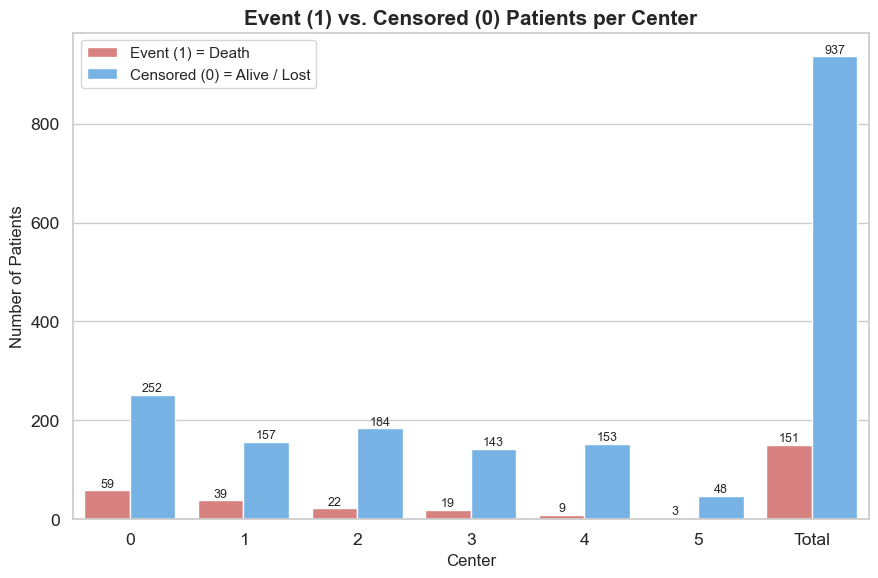

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter to combined train+test ("all") rows only
summary_plot = summary_full[summary_full["split"] == "all"].copy()
summary_plot["center"] = summary_plot["center"].astype(str)

# Melt data for grouped plotting (one bar for each status per center)
summary_melted = summary_plot.melt(
    id_vars="center",
    value_vars=["n_events", "n_censored"],
    var_name="status",
    value_name="count"
)

status_labels = {
    "n_events": "Event (1) = Death",
    "n_censored": "Censored (0) = Alive / Lost"
}
summary_melted["status_label"] = summary_melted["status"].map(status_labels)

# Plot:
plt.figure(figsize=(9, 6))
sns.set(style="whitegrid", palette="muted", font_scale=1.15)

ax = sns.barplot(
    data=summary_melted,
    x="center",
    y="count",
    hue="status_label",
    palette=["#E57373", "#64B5F6"]
)

# Titles and labels:
ax.set_title("Event (1) vs. Censored (0) Patients per Center", fontsize=15, weight="bold")
ax.set_xlabel("Center", fontsize=12)
ax.set_ylabel("Number of Patients", fontsize=12)
ax.legend(title="", fontsize=11)

# labels on bars:
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type="edge", fontsize=9)

plt.tight_layout()
plt.show()

### Kaplan–Meier survival curves per center:  

- It identifies the probability of survival at a point in time (in terms of days since subscription inception) using some simple statistical calculations derived from the observed data

- The method calculates the probability of surviving past certain time points, considering both events (e.g., death) and censored data (patients lost to follow-up or still alive at last observation).
- At each event time, the survival probability is updated by multiplying the previous probability by the proportion of individuals surviving at that time.
- Censored observations are accounted for by removing them from the risk set at the time they are censored, but they do not count as events.

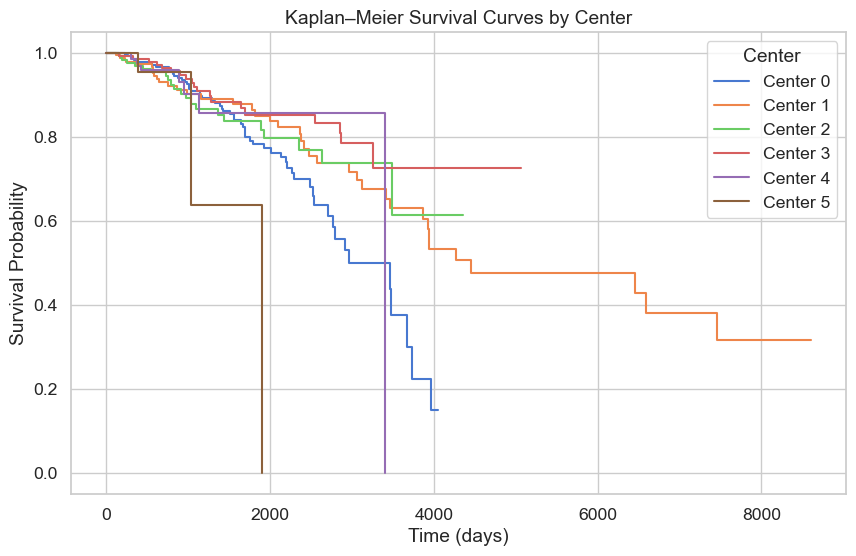

In [35]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
kmf = KaplanMeierFitter()

for center in sorted(df_all["center"].unique()):
    mask = df_all["center"] == center
    kmf.fit(
        durations=df_all.loc[mask, "time"],
        event_observed=df_all.loc[mask, "event"],
        label=f"Center {center}"
    )
    kmf.plot(ci_show=False)

plt.title("Kaplan–Meier Survival Curves by Center")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.legend(title="Center")
plt.show()

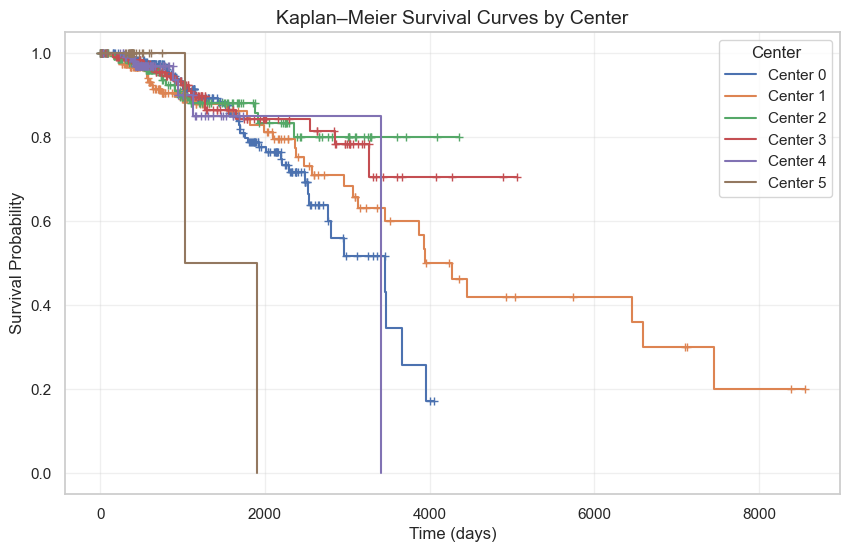

In [ ]:
from lifelines import KaplanMeierFitter

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
kmf = KaplanMeierFitter()

for center in sorted(df_all["center"].unique()):
    mask = df_all["center"] == center
    
    kmf.fit(
        durations=df_all.loc[mask, "time"],
        event_observed=df_all.loc[mask, "event"],
        label=f"Center {center}"
    )
    
    # plot survival function with censoring ticks
    kmf.plot(ci_show=False, show_censors=True, censor_styles={'marker': '+', 'ms': 6})

plt.title("Kaplan–Meier Survival Curves by Center", fontsize=14)
plt.xlabel("Time (days)")  # or 'months' if you converted it
plt.ylabel("Survival Probability")
plt.legend(title="Center")
plt.grid(alpha=0.3)
plt.show()


### Survival time distribution (event=1 vs 0):
- Each box shows the distribution of survival times for that group:
    - The line inside the box is the median survival time.
    - The box edges represent the 25th and 75th percentiles (the interquartile range).
    - The whiskers show the range of most data points (usually 1.5× IQR).
    - Dots beyond the whiskers are outliers (patients with unusually long follow-up or survival).

/var/folders/jv/1hzcplmx7550fjkm1q4b5bmc0000gn/T/ipykernel_31436/3857186793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x="event", y="time", palette="Set2")


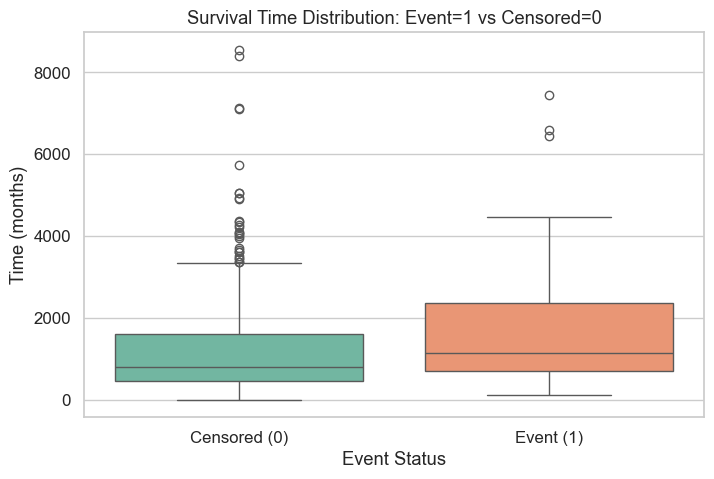

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_all, x="event", y="time", palette="Set2")
plt.title("Survival Time Distribution: Event=1 vs Censored=0")
plt.xlabel("Event Status")
plt.ylabel("Time (months)")
plt.xticks([0,1], ["Censored (0)", "Event (1)"])
plt.show()

Interpretation:
- The “Censored (0)” group tends to have shorter recorded times, because those are patients who were still alive or lost early, so their observation stopped before the event occurred.
- The “Event (1)” group usually has longer times, since it takes time for the event (death in this case) to occur.
- The spread of the boxes shows variability in follow-up: centers or patients differ in how long they were observed.
- Outliers near the top indicate patients who survived or were followed for several thousand days (10+ years).

Event rate vs survival time relationship:

### Censoring over time (Empirical CDF):
- ECDF plot (Empirical Cumulative Distribution Function plot) shows the proportion of data points that are less than or equal to each value on the x-axis. For each value of "time" in your dataset, the ECDF curve rises to indicate the fraction of patients whose survival time is less than or equal to that value.
- Graph:
    - X-axis: Time in days --> how long each patient was followed.
    - Y-axis: Cumulative probability —-> fraction of patients who have reached that time point.
- Interpretation:
    - Curve position (left vs right):
        - The blue curve (events) rises faster, meaning events (i.e. death) tend to occur earlier.
        - The red curve (censored) is shifted to the right, meaning censored patients tend to be followed longer (they survive or remain event-free longer).
    - Cumulative probability ≈ 1 around 8000 days:
        - By ~8000 days (≈ 22 years), almost all patients have either had an event or been censored.
    - Separation between curves:
        - The gap between blue and red indicates that censored patients systematically have larger follow-up times, which is typical in survival data: those who haven’t had the event by the end of study tend to live longer.
    - Early steepness of blue curve:
        - The steep rise of the blue line near the origin implies that many events occur early in follow-up (xq la linea crece rápido al princiipio).

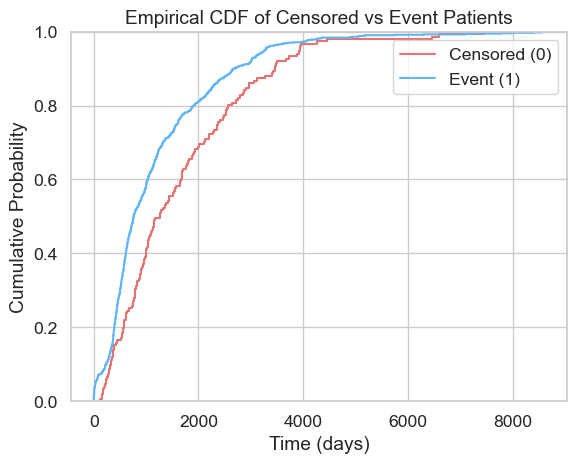

In [41]:
sns.ecdfplot(data=df_all, x="time", hue="event", palette=["#64B5F6","#E57373"])
plt.title("Empirical CDF of Censored vs Event Patients")
plt.xlabel("Time (days)")
plt.ylabel("Cumulative Probability")
plt.legend(labels=["Censored (0)", "Event (1)"])
plt.show()
